<a href="https://colab.research.google.com/github/aparna-2001/system-biology/blob/main/systems_biologyipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip uninstall -y numpy scipy
!pip install tellurium


Found existing installation: numpy 2.4.4
Uninstalling numpy-2.4.4:
  Successfully uninstalled numpy-2.4.4
Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.


In [2]:
import tellurium as te
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sc
import networkx as nx

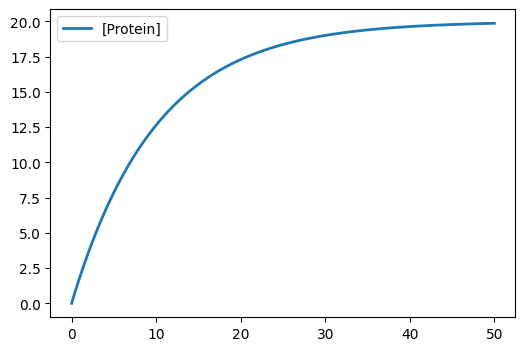

In [4]:


# A simple gene that produces protein and degrades it
model = te.loada('''
  production: -> Protein; k1
  degradation: Protein -> ; k2 * Protein

  k1 = 2.0    # production rate
  k2 = 0.1   # degradation rate
  Protein = 0 # starting amount
''')

result = model.simulate(0, 50, 500)
model.plot()

/tmp/ipykernel_2310/1679834414.py:30: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



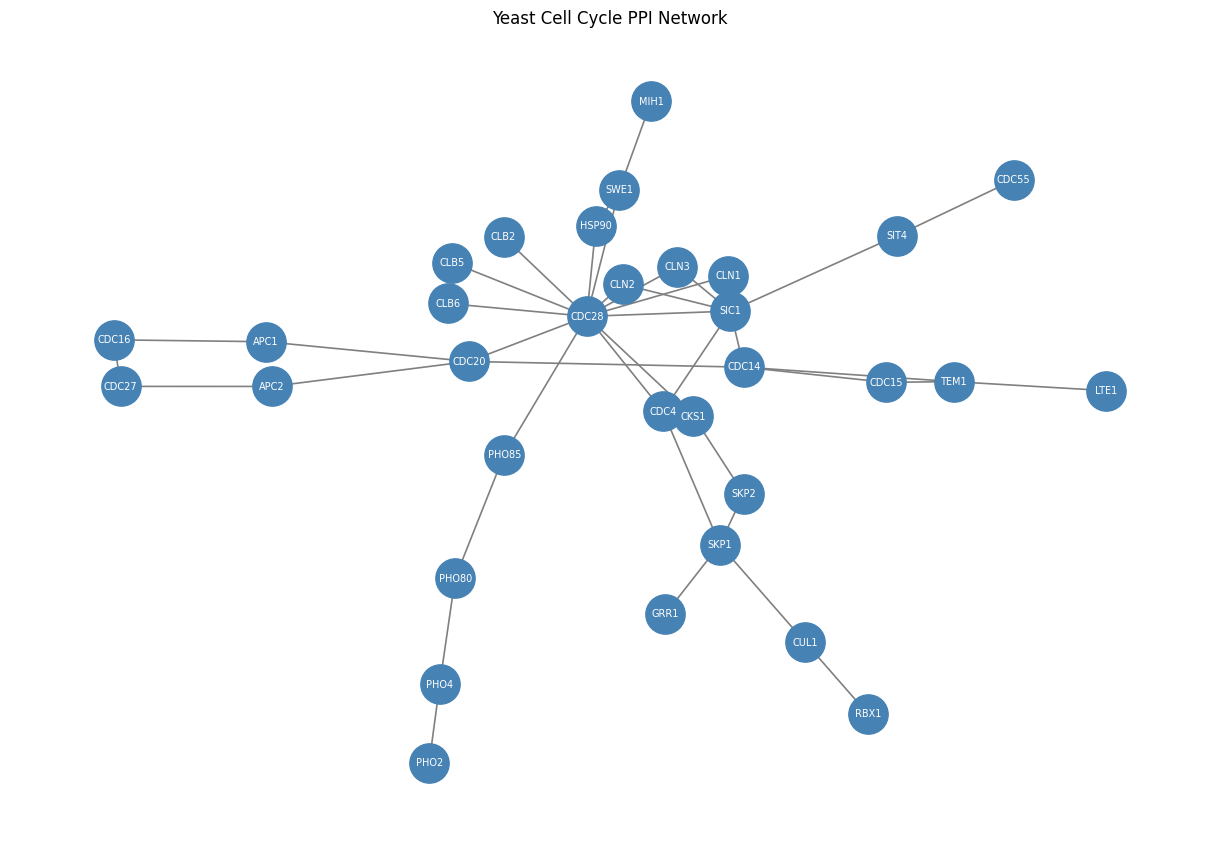

Nodes (proteins): 33
Edges (interactions): 41


In [5]:


# Real yeast PPI data — curated high-confidence interactions
# Source: BioGRID / Jeong et al. 2001 (Nature) core dataset
edges = [
    ("CDC28","CLN1"),("CDC28","CLN2"),("CDC28","CLN3"),
    ("CDC28","SIC1"),("CDC28","CDC20"),("CDC28","CKS1"),
    ("CLN1","SIC1"),("CLN2","SIC1"),("CLN3","SIC1"),
    ("SIC1","CDC4"),("CDC4","SKP1"),("SKP1","CUL1"),
    ("CUL1","RBX1"),("CDC20","APC1"),("APC1","CDC16"),
    ("CDC16","CDC27"),("CDC27","APC2"),("APC2","CDC20"),
    ("CKS1","SKP2"),("SKP2","SKP1"),("CLN1","CDC28"),
    ("SWE1","CDC28"),("MIH1","SWE1"),("HSP90","CDC28"),
    ("HSP90","SWE1"),("CDC55","SIT4"),("SIT4","SIC1"),
    ("CDC14","SIC1"),("CDC14","CDC20"),("TEM1","CDC14"),
    ("LTE1","TEM1"),("CDC15","TEM1"),("CDC15","CDC14"),
    ("CLB2","CDC28"),("CLB5","CDC28"),("CLB6","CDC28"),
    ("CDC28","PHO85"),("PHO85","PHO80"),("PHO80","PHO4"),
    ("PHO4","PHO2"),("GRR1","SKP1"),("CDC4","CDC28")
]

G = nx.Graph()
G.add_edges_from(edges)

# Visualize it
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='steelblue',
        node_size=800, font_size=7, font_color='white',
        edge_color='gray', width=1.2)
plt.title("Yeast Cell Cycle PPI Network")
plt.tight_layout()
plt.show()

print(f"Nodes (proteins): {G.number_of_nodes()}")
print(f"Edges (interactions): {G.number_of_edges()}")

In [6]:
# Degree of every protein
degree_dict = dict(G.degree())

for protein, deg in sorted(degree_dict.items(), key=lambda x: -x[1]):
    print(f"{protein}: {deg}")

CDC28: 13
SIC1: 7
CDC20: 4
SKP1: 4
CDC14: 4
CDC4: 3
SWE1: 3
TEM1: 3
CLN1: 2
CLN2: 2
CLN3: 2
CKS1: 2
CUL1: 2
APC1: 2
CDC16: 2
CDC27: 2
APC2: 2
SKP2: 2
HSP90: 2
SIT4: 2
CDC15: 2
PHO85: 2
PHO80: 2
PHO4: 2
RBX1: 1
MIH1: 1
CDC55: 1
LTE1: 1
CLB2: 1
CLB5: 1
CLB6: 1
PHO2: 1
GRR1: 1


/tmp/ipykernel_2310/1606370019.py:9: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



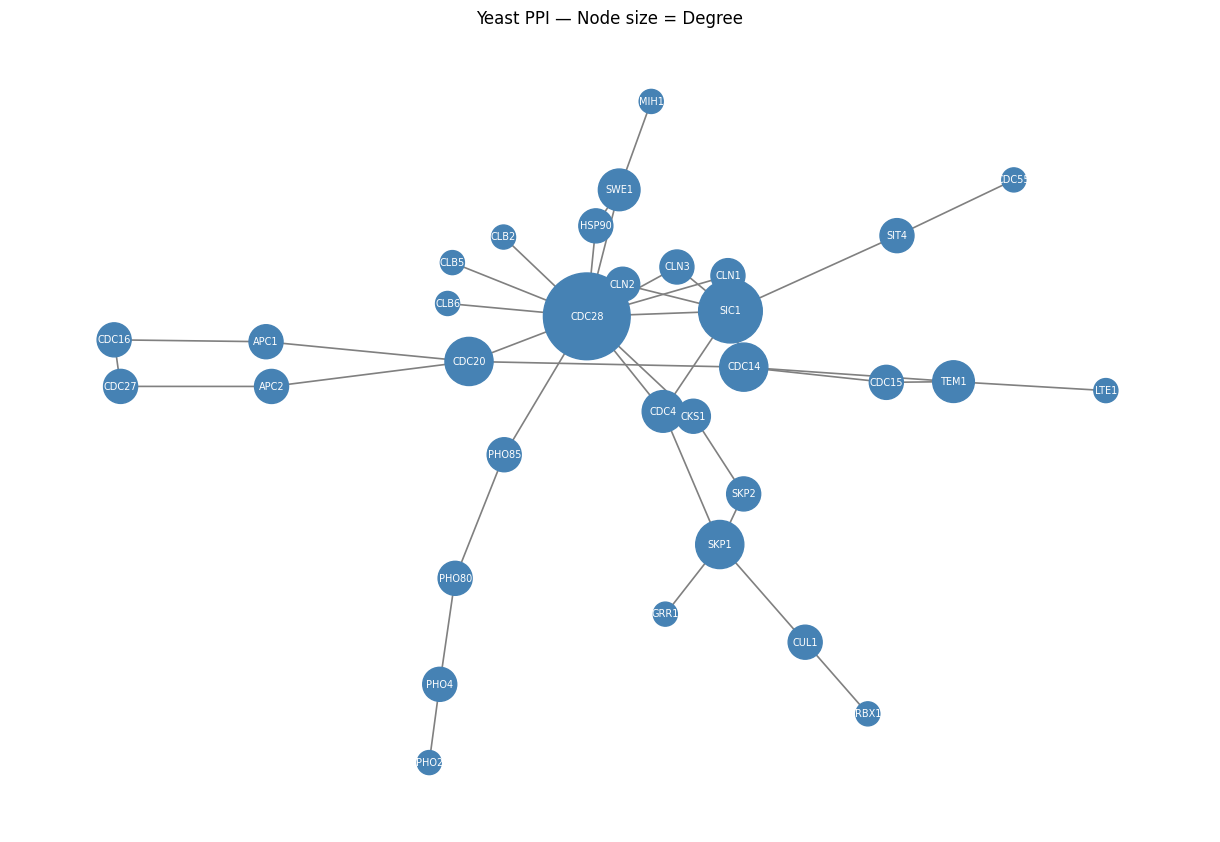

In [7]:
# Visualize with node size proportional to degree
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)
node_sizes = [degree_dict[n] * 300 for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color='steelblue',
        node_size=node_sizes, font_size=7, font_color='white',
        edge_color='gray', width=1.2)
plt.title("Yeast PPI — Node size = Degree")
plt.tight_layout()
plt.show()

In [8]:
# What happens to the network if we remove CDC28?
G_removed = G.copy()
G_removed.remove_node("CDC28")

# Count connected components
components = list(nx.connected_components(G_removed))
print(f"Components after removing CDC28: {len(components)}")
print()
for i, comp in enumerate(components):
    print(f"Component {i+1}: {comp}")

Components after removing CDC28: 6

Component 1: {'CLN1', 'SKP2', 'LTE1', 'CDC15', 'CDC20', 'CKS1', 'SKP1', 'CUL1', 'SIC1', 'TEM1', 'CLN3', 'CDC27', 'CDC4', 'SIT4', 'CDC14', 'CDC55', 'CLN2', 'CDC16', 'APC1', 'APC2', 'RBX1', 'GRR1'}
Component 2: {'MIH1', 'SWE1', 'HSP90'}
Component 3: {'CLB2'}
Component 4: {'CLB5'}
Component 5: {'CLB6'}
Component 6: {'PHO4', 'PHO80', 'PHO85', 'PHO2'}


In [9]:
#density

density = nx.density(G)
print(f"Network density: {density:.4f}")

# For context, let's see what density 1.0 would look like
n = G.number_of_nodes()
max_possible_edges = n * (n-1) / 2
actual_edges = G.number_of_edges()

print(f"Proteins in network: {n}")
print(f"Actual interactions: {actual_edges}")
print(f"Maximum possible interactions: {int(max_possible_edges)}")
print(f"Percentage of possible interactions that exist: {density*100:.2f}%")

Network density: 0.0777
Proteins in network: 33
Actual interactions: 41
Maximum possible interactions: 528
Percentage of possible interactions that exist: 7.77%


Shortest path from SIC1 to PHO4: ['SIC1', 'CDC28', 'PHO85', 'PHO80', 'PHO4']
Path length: 4 steps

Characteristic path length: 3.4432


/tmp/ipykernel_2310/3334594351.py:22: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



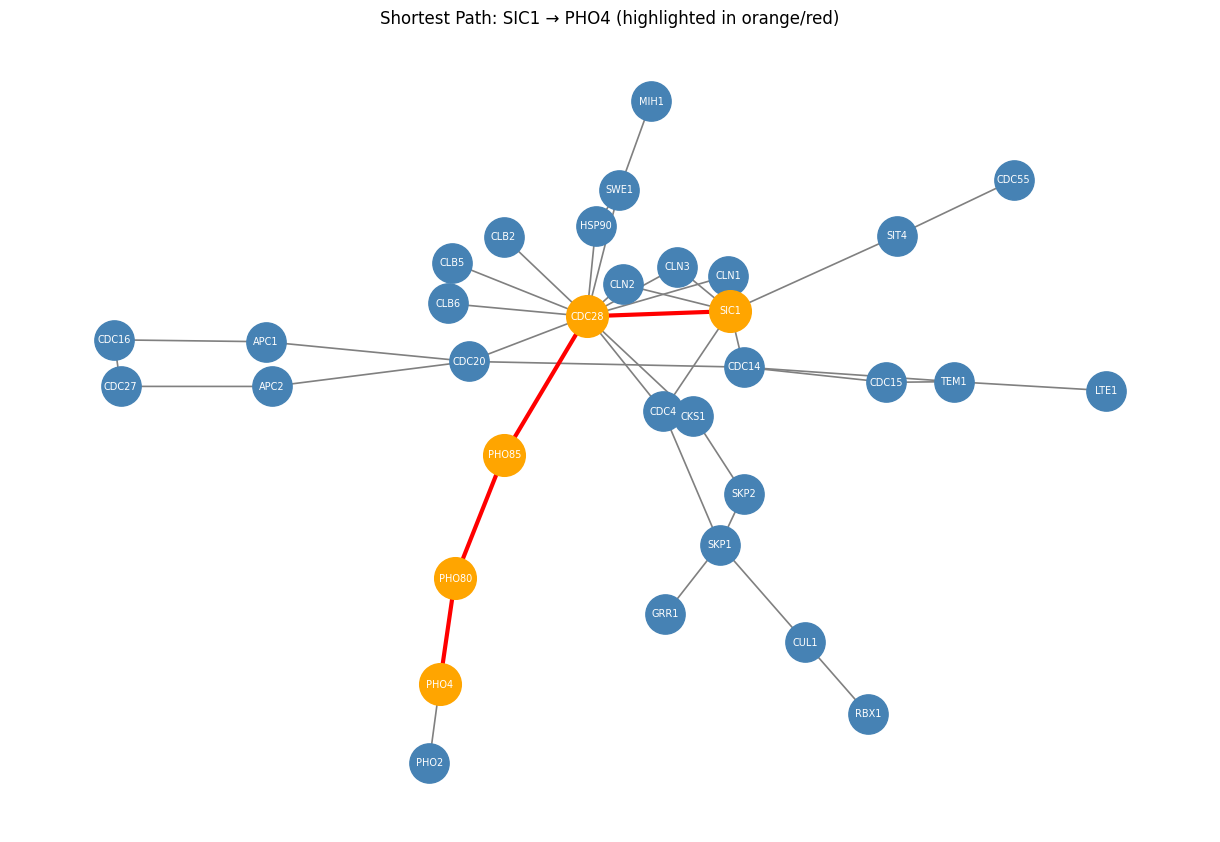

In [10]:
# Shortest path between two specific proteins
path = nx.shortest_path(G, "SIC1", "PHO4")
print(f"Shortest path from SIC1 to PHO4: {path}")
print(f"Path length: {len(path)-1} steps")

# Characteristic path length (average shortest path)
avg_path = nx.average_shortest_path_length(G)
print(f"\nCharacteristic path length: {avg_path:.4f}")

# Visualize the path
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)
path_edges = list(zip(path, path[1:]))
nx.draw(G, pos, with_labels=True, node_color='steelblue',
        node_size=800, font_size=7, font_color='white',
        edge_color='gray', width=1.2)
nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                       edge_color='red', width=3)
nx.draw_networkx_nodes(G, pos, nodelist=path,
                       node_color='orange', node_size=900)
plt.title("Shortest Path: SIC1 → PHO4 (highlighted in orange/red)")
plt.tight_layout()
plt.show()

Shortest path from SIC1 to SKP1: ['SIC1', 'CDC4', 'SKP1']
Path length: 2 steps


/tmp/ipykernel_2310/4130741712.py:19: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



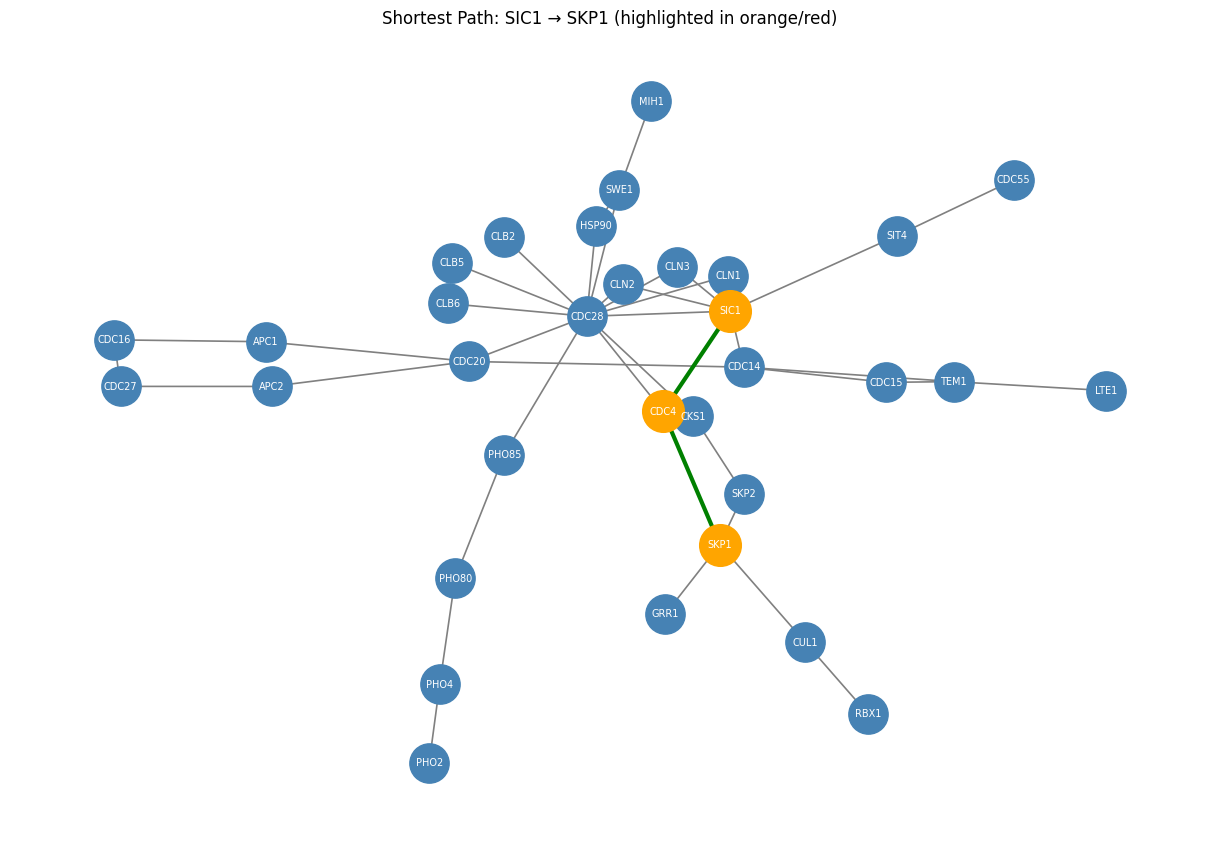

In [12]:
# Shortest path between two specific proteins
path_2 = nx.shortest_path(G, "SIC1", "SKP1")
print(f"Shortest path from SIC1 to SKP1: {path_2}")
print(f"Path length: {len(path)-1} steps")


# Visualize the path
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)
path_edges = list(zip(path_2, path_2[1:]))
nx.draw(G, pos, with_labels=True, node_color='steelblue',
        node_size=800, font_size=7, font_color='white',
        edge_color='gray', width=1.2)
nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                       edge_color='green', width=3)
nx.draw_networkx_nodes(G, pos, nodelist=path_2,
                       node_color='orange', node_size=900)
plt.title("Shortest Path: SIC1 → SKP1 (highlighted in orange/red)")
plt.tight_layout()
plt.show()


In [13]:
# Diameter of the network
diameter = nx.diameter(G)
print(f"Network diameter: {diameter}")

# Find which two proteins are furthest apart
periphery = nx.periphery(G)
center = nx.center(G)

print(f"\nPeriphery proteins (furthest from everything): {periphery}")
print(f"Center proteins (closest to everything): {center}")

# Find the actual longest shortest path
eccentricities = nx.eccentricity(G)
for protein, ecc in sorted(eccentricities.items(), key=lambda x: -x[1]):
    print(f"{protein}: eccentricity {ecc}")





Network diameter: 8

Periphery proteins (furthest from everything): ['RBX1', 'LTE1', 'PHO2']
Center proteins (closest to everything): ['CDC28']
RBX1: eccentricity 8
LTE1: eccentricity 8
PHO2: eccentricity 8
CUL1: eccentricity 7
CDC16: eccentricity 7
CDC27: eccentricity 7
CDC55: eccentricity 7
TEM1: eccentricity 7
CDC15: eccentricity 7
PHO4: eccentricity 7
GRR1: eccentricity 7
SKP1: eccentricity 6
APC1: eccentricity 6
APC2: eccentricity 6
SKP2: eccentricity 6
MIH1: eccentricity 6
SIT4: eccentricity 6
CDC14: eccentricity 6
PHO80: eccentricity 6
CLN1: eccentricity 5
CLN2: eccentricity 5
CLN3: eccentricity 5
SIC1: eccentricity 5
CDC20: eccentricity 5
CKS1: eccentricity 5
CDC4: eccentricity 5
SWE1: eccentricity 5
HSP90: eccentricity 5
CLB2: eccentricity 5
CLB5: eccentricity 5
CLB6: eccentricity 5
PHO85: eccentricity 5
CDC28: eccentricity 4


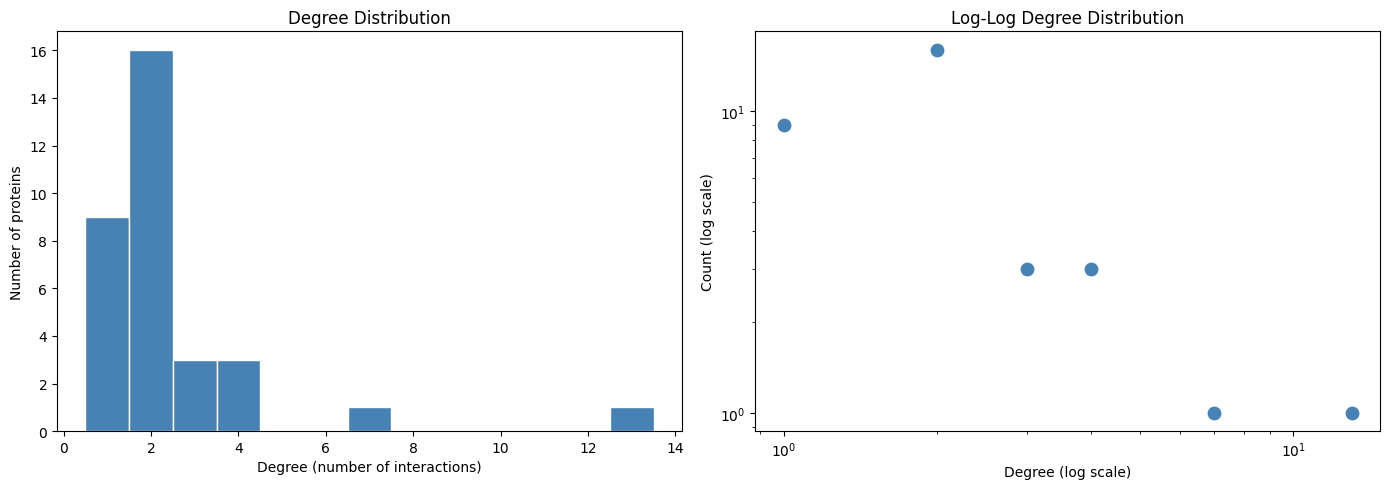

Degree : Number of proteins
  Degree  1 : 9 proteins  █████████
  Degree  2 : 16 proteins  ████████████████
  Degree  3 : 3 proteins  ███
  Degree  4 : 3 proteins  ███
  Degree  7 : 1 proteins  █
  Degree 13 : 1 proteins  █


In [15]:


# Get degree of all proteins
degrees = [d for n, d in G.degree()]

# Plot degree distribution
plt.figure(figsize=(14,5))

# Plot 1 — Raw distribution
plt.subplot(1,2,1)
plt.hist(degrees, bins=range(1, max(degrees)+2),
         color='steelblue', edgecolor='white', align='left')
plt.xlabel("Degree (number of interactions)")
plt.ylabel("Number of proteins")
plt.title("Degree Distribution")

# Plot 2 — Log-log plot
plt.subplot(1,2,2)
degree_counts = {}
for d in degrees:
    degree_counts[d] = degree_counts.get(d, 0) + 1

x = list(degree_counts.keys())
y = list(degree_counts.values())

plt.scatter(x, y, color='steelblue', s=80)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Degree (log scale)")
plt.ylabel("Count (log scale)")
plt.title("Log-Log Degree Distribution")

plt.tight_layout()
plt.show()

# Print the distribution
print("Degree : Number of proteins")
for deg, count in sorted(degree_counts.items()):
    print(f"  Degree {deg:2d} : {count} proteins  {'█' * count}")
